# JP Morgan Quantitative Research Forage Experience

In [1]:
#Import needed libraries for entire notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

## Task 1: Investigate and analyze price data

In [2]:
df = pd.read_csv("Nat_Gas.csv")
df.head()

,Dates,Prices
0,10/31/20,10.1
1,11/30/20,10.3
2,12/31/20,11.0
3,1/31/21,10.9
4,2/28/21,10.9


In [3]:
df["Dates"] = pd.to_datetime(df["Dates"],format="%m/%d/%y")
df["Dates"].head()

0   2020-10-31
1   2020-11-30
2   2020-12-31
3   2021-01-31
4   2021-02-28
Name: Dates, dtype: datetime64[ns]

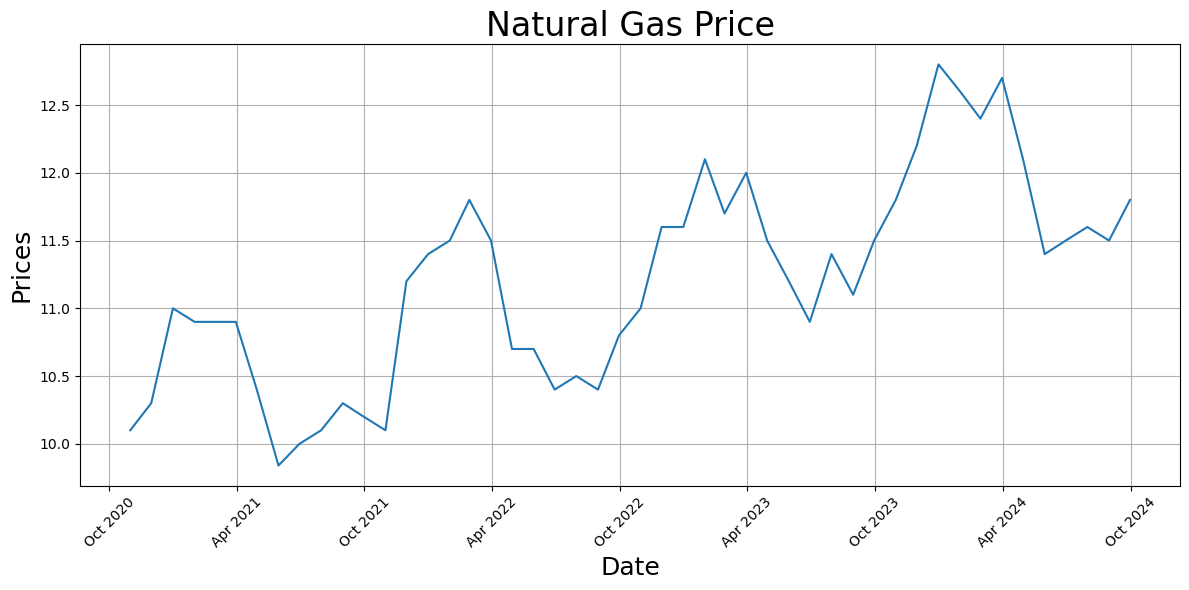

In [4]:
#Initial plot of the Natural Gas price
import matplotlib.dates as mdates
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(df["Dates"],df["Prices"])

ax.set_title("Natural Gas Price",fontsize=24)
ax.set_xlabel("Date",fontsize=18)
ax.set_ylabel("Prices",fontsize=18)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

### Observations
The data exhibits an upward trend, with seasonal fluctuations that a linear model would fail to capture. For this reason, within the model, sine and cosine transformations will be included to engineer cyclical features in the model.

In [5]:
df["time"] = np.arange(len(df))
df["month"] = df["Dates"].dt.month
df["sin_month"] = np.sin(2*np.pi*df["month"]/12)
df["cos_month"] = np.cos(2*np.pi*df["month"]/12)
df.head()

,Dates,Prices,time,month,sin_month,cos_month
0,2020-10-31,10.1,0,10,-8.660254e-01,0.500000
1,2020-11-30,10.3,1,11,-5.000000e-01,0.866025
2,2020-12-31,11.0,2,12,-2.449294e-16,1.000000
3,2021-01-31,10.9,3,1,5.000000e-01,0.866025
4,2021-02-28,10.9,4,2,8.660254e-01,0.500000


In [6]:
#Fitting the data with a linear regression model
X = df[["time","sin_month","cos_month"]]
y = df["Prices"]
model = LinearRegression()
model.fit(X,y)
predictions = model.predict(X)

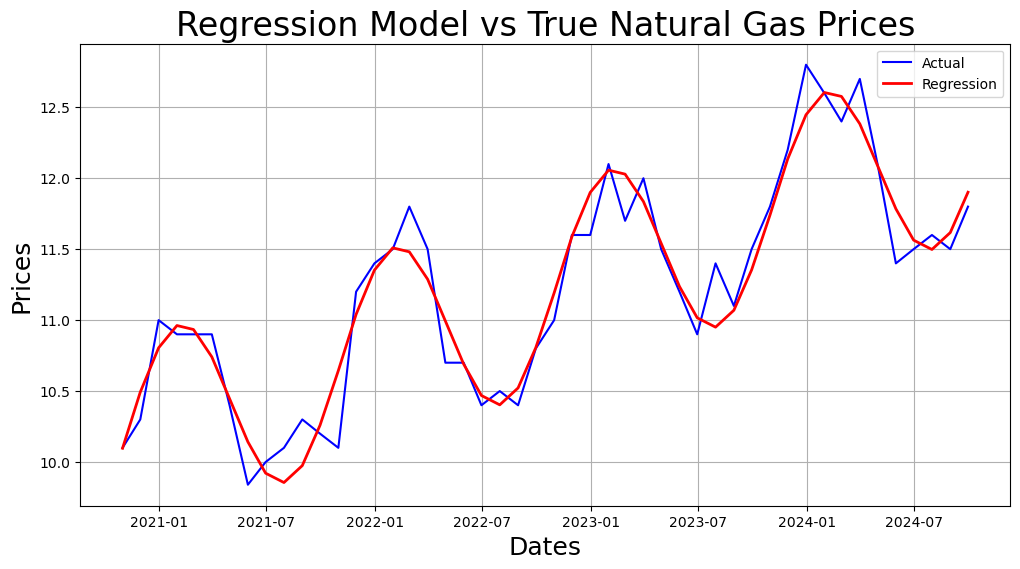

In [7]:
#Plotting model prediction and true prices on same graph
plt.figure(figsize=(12,6))

plt.plot(df["Dates"], df["Prices"], 'b', label = 'Actual')
plt.plot(df["Dates"], predictions, 'r', label = 'Regression', lw = 2)

plt.legend()
plt.xlabel("Dates",fontsize=18)
plt.ylabel("Prices",fontsize=18)
plt.title("Regression Model vs True Natural Gas Prices",fontsize=24)
plt.grid(True)
plt.show()

In [8]:
print(f"R² = {model.score(X, y):.3f}")

R² = 0.929


### Model Evaluation
The regression model captures the overall trend and annual seasonality well while smoothing short-term fluctuations. This suggests that the chosen features provide a reasonable approximation to the observed behaviour of natural gas prices.

In [9]:
def estimate_price(date_string):
    date = pd.to_datetime(date_string)
    month = date.month
    
    start_date = df["Dates"].min()
    
    time = (date.year - start_date.year)*12 + (date.month - start_date.month)
    
    sin_month = np.sin(2*np.pi*month/12)
    cos_month = np.cos(2*np.pi*month/12)
    
    X_new = pd.DataFrame({"time":[time], "sin_month":[sin_month], "cos_month":[cos_month]})
    predicted_price = model.predict(X_new)[0]
    
    return round(float(predicted_price),2)

In [10]:
price = estimate_price("2025-06-15")
print("Estimated price on 15 June 2025:", price)

Estimated price on 15 June 2025: 12.11


## Task 2: Commodity Storage Contract Pricing

This function prices a simple commodity storage contract using the estimated gas price model developed in Task 1.

The client provides injection dates, withdrawal dates, and volumes. For each injection-withdrawal pair, the model:

1. Estimates the gas price on the injection date.
2. Estimates the gas price on the withdrawal date.
3. Calculates the purchase cost.
4. Calculates the sale revenue.
5. Subtracts storage costs.
6. Adds the result to the total contract value.

### Assumptions

- Each injection date is paired with the corresponding withdrawal date.
- Gas is injected and withdrawn on the specified dates.
- Interest rates are zero, so no discounting is applied.
- Storage costs are charged as a flat daily cost for each storage period.
- Transport delays, weekends, market holidays, and bank holidays are ignored.
- Capacity, injection rate, and withdrawal rate limits are checked independently for each transaction.
- The model does not optimise the storage schedule or track total inventory across overlapping periods.

### Contract value formula

For each injection-withdrawal pair:

Contract value = sale revenue - purchase cost - storage cost

where:

sale revenue = sell price × volume

purchase cost = buy price × volume

storage cost = days stored × daily storage cost

The total contract value is the sum of the values across all injection-withdrawal pairs.

In [11]:
#Here is the pricing function
def price_storage_contract(injection_dates,withdrawal_dates,volumes,daily_storage_cost,max_storage,injection_rate,withdrawal_rate):
    
    if len(injection_dates) != len(withdrawal_dates) or len(injection_dates) != len(volumes):
        raise ValueError("Injection dates, withdrawal dates, and volumes must have the same length.")

    total_contract_value = 0

    for i in range(len(volumes)):
        injection_date = injection_dates[i]
        withdrawal_date = withdrawal_dates[i]
        volume = volumes[i]

        buy_price = estimate_price(injection_date)
        sell_price = estimate_price(withdrawal_date)

        injection = pd.to_datetime(injection_date)
        withdrawal = pd.to_datetime(withdrawal_date)
        days_stored = (withdrawal - injection).days

        if days_stored < 0:
            raise ValueError("Withdrawal date must be after injection date.")

        if volume > max_storage:
            raise ValueError("Storage capacity exceeded")

        if volume > injection_rate:
            raise ValueError("Injection rate exceeded")

        if volume > withdrawal_rate:
            raise ValueError("Withdrawal rate exceeded")

        storage_cost = days_stored * daily_storage_cost

        purchase_cost = buy_price * volume
        sale_revenue = sell_price * volume

        contract_value = sale_revenue - purchase_cost - storage_cost

        total_contract_value += contract_value

    return round(total_contract_value, 2)

In [12]:
#Test it
price_storage_contract(injection_dates=["2025-06-15", "2025-07-15"],withdrawal_dates=["2025-12-15", "2026-01-15"],volumes=[100, 80],daily_storage_cost=0.005,max_storage=200,injection_rate=150,withdrawal_rate=150)

273.17

This prototype pairs each injection date with a corresponding withdrawal date and prices each leg independently. It checks volume constraints for each trade, but does not yet optimise storage inventory across all possible injection and withdrawal schedules.

## Task 3: Credit risk analysis

### Data Exploration

The dataset contains information on loan borrowers, including income, outstanding loan amount, total debt, years employed, FICO score, and whether the borrower has previously defaulted.

The target variable is `default`, where:

- `0` means the borrower did not default
- `1` means the borrower defaulted

The `customer_id` column is only an identifier, so it will not be used as a feature in the model.

In [13]:
import pandas as pd
df = pd.read_csv("Task 3 and 4_Loan_Data.csv")
df.head()

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10000 non-null  int64  
 1   credit_lines_outstanding  10000 non-null  int64  
 2   loan_amt_outstanding      10000 non-null  float64
 3   total_debt_outstanding    10000 non-null  float64
 4   income                    10000 non-null  float64
 5   years_employed            10000 non-null  int64  
 6   fico_score                10000 non-null  int64  
 7   default                   10000 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 625.1 KB


In [15]:
df["default"].value_counts(normalize=True)

default
0    0.8149
1    0.1851
Name: proportion, dtype: float64

### Feature Selection and Train-Test Split

The aim is to predict the probability that a borrower defaults. Therefore, the target variable is `default`.

The input features are all borrower characteristics except `customer_id` and `default`.

The data is split into a training set and a test set. The model is fitted only on the training data, while the test data is kept unseen until evaluation. This gives a fairer estimate of how the model performs on new borrowers.

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = df.drop(columns=["customer_id","default"])
y = df["default"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

### Logistic Regression Model

I use logistic regression because the task is a binary classification problem: the borrower either defaults or does not default.

Logistic regression is also useful because it provides predicted probabilities, not just class predictions. This is important because the expected loss calculation requires the probability of default.

A standard scaler is included in a pipeline before the logistic regression model. This scales the input features so that variables measured on different scales, such as income and FICO score, can be handled more effectively by the optimisation algorithm.

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

model = Pipeline([("scaler", StandardScaler()),("logreg", LogisticRegression(max_iter=1000))])
model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('logreg', LogisticRegression(max_iter=1000))])

In [18]:
pd_predictions = model.predict_proba(X_test)[:, 1]
print(pd_predictions.round(3)[:10])

[0.    0.008 1.    0.    0.    0.    0.    0.    1.    0.   ]


The predicted probabilities represent the estimated probability that each borrower will default. These probabilities are later used to calculate the expected loss for a loan.

### Model Evaluation

The model is evaluated on the test set using accuracy and a confusion matrix.

Accuracy measures the proportion of correct predictions. However, for credit risk, the confusion matrix is also important because it shows the types of errors being made.

In particular, false negatives are important because they represent borrowers who actually defaulted but were predicted not to default.

In [19]:
from sklearn.metrics import accuracy_score , confusion_matrix

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(accuracy)
print(cm)

0.9955
[[1650    2]
 [   7  341]]


### Evaluation Results

The logistic regression model achieved an accuracy of 99.55% on the test set.

The confusion matrix was:


$$\begin{bmatrix}
1650 & 2 \\
7 & 341
\end{bmatrix}$$


This means:

- 1650 borrowers were correctly predicted as not defaulting
- 2 borrowers were incorrectly predicted as defaulting
- 7 borrowers were incorrectly predicted as not defaulting
- 341 borrowers were correctly predicted as defaulting

The model performs very well on this dataset, with only a small number of incorrect predictions.

### Expected Loss Function

The task asks for a function that estimates the expected loss on a loan.

The expected loss is calculated as:

$$\text{Expected Loss}=P(\text{Default})\times(1 - \text{Recovery Rate})\times\text{Loan Amount}$$

The recovery rate is given as 10%, so the loss given default is 90%.

The function below takes a borrower's loan details, predicts their probability of default using the trained model, and then calculates the expected loss.

In [20]:
def calculate_expected_loss(borrower):

    borrower_df = pd.DataFrame([borrower])

    probability_default = model.predict_proba(borrower_df)[0, 1]

    loss = probability_default * 0.9 * borrower["loan_amt_outstanding"]

    return loss

In [21]:
new_borrower = {"credit_lines_outstanding": 2,"loan_amt_outstanding": 10000, "total_debt_outstanding": 15000, "income": 50000,"years_employed": 5,"fico_score": 680}
print(f"Expected loss: {calculate_expected_loss(new_borrower):.2f}")

Expected loss: 26.00


## Task 4: Bucket FICO Scores

### Approach

This task creates a credit rating system by mapping FICO scores into a fixed number of buckets.

The aim is to choose bucket boundaries that group borrowers with similar default behaviour. I use the log-likelihood objective suggested in the task prompt, then use dynamic programming to find the bucket boundaries that maximise the total log-likelihood.

A lower rating represents a better credit score. In this implementation, rating 1 is the best rating and rating 10 is the worst rating.

### Log-likelihood score

For each bucket, let:

- \(n\) be the number of loans in the bucket
- \(k\) be the number of defaults in the bucket
- \(p = k/n\) be the observed default rate

The log-likelihood score for one bucket is:

\[
k\log(p) + (n-k)\log(1-p)
\]

This measures how well a single default probability explains the borrowers in that bucket. Higher log-likelihood values are better. Since log probabilities are usually negative, this means values closer to 0 are better.

The cases \(k=0\) and \(k=n\) are handled separately to avoid taking \(\log(0)\).

In [22]:
# Function that calculates the log-likelihood score for one bucket. n = number of loans in the bucket , k = number of defaults in the bucket.
def calculate_log_likelihood(k, n):
    if n == 0:
        return 0
    
    if k == 0 or k == n:
        return 0
    
    p = k / n
    
    return k * np.log(p) + (n - k) * np.log(1 - p)

In [23]:
calculate_log_likelihood(12, 100)

np.float64(-36.69249912727096)

### Preparing the FICO data

The rating depends only on FICO score, so the dataset is first grouped by `fico_score`.

For each unique FICO score, I calculate:

- `n`: the number of borrowers with that FICO score
- `k`: the number of borrowers with that FICO score who defaulted

This gives the information needed to evaluate any possible FICO bucket.

In [24]:
fico_data = df.groupby("fico_score").agg(n=("default", "count"),k=("default", "sum")).reset_index().sort_values("fico_score")
fico_data.head()

,fico_score,n,k
0,408,1,0
1,409,1,1
2,418,1,1
3,425,1,1
4,438,1,1


In [25]:
scores = fico_data["fico_score"].values
n = fico_data["n"].values
k = fico_data["k"].values

scores[:5], n[:5], k[:5]

(array([408, 409, 418, 425, 438]),
 array([1, 1, 1, 1, 1]),
 array([0, 1, 1, 1, 1]))

### Prefix sums

Prefix sums are used to calculate the number of loans and defaults in any possible bucket efficiently.

Once the FICO scores are sorted, a bucket is represented by a start index and an end index. The total number of loans and defaults in that interval can then be found by subtracting prefix sums, instead of repeatedly looping through the data.

In [26]:
n_prefix = np.concatenate([[0], np.cumsum(n)])
k_prefix = np.concatenate([[0], np.cumsum(k)])

In [27]:
start = 0
end = 5

bucket_n = n_prefix[end] - n_prefix[start]
bucket_k = k_prefix[end] - k_prefix[start]

print(bucket_n)
print(bucket_k)
print(calculate_log_likelihood(bucket_k, bucket_n))

5
4
-2.5020121176909393


In [28]:
# Calculates the log-likelihood for the bucket containing FICO rows from start up to, but not including, end.

def get_bucket_log_likelihood(start, end):

    bucket_n = n_prefix[end] - n_prefix[start]
    bucket_k = k_prefix[end] - k_prefix[start]
    
    return calculate_log_likelihood(bucket_k, bucket_n)

In [29]:
print(get_bucket_log_likelihood(0, 5))
print(get_bucket_log_likelihood(0, 20))

-2.5020121176909393
-18.325929061646804


In [30]:
#Number of unique FICO scores
m = len(scores)

bucket_scores = np.full((m, m + 1), -np.inf)

for start in range(m):
    for end in range(start + 1, m + 1):
        bucket_scores[start, end] = get_bucket_log_likelihood(start, end)

In [31]:
print(bucket_scores[0, 5])
print(get_bucket_log_likelihood(0, 5))

-2.5020121176909393
-2.5020121176909393


### Dynamic programming

The dynamic programming table `dp` is used to find the best bucket boundaries.

`dp[b, i]` stores the maximum total log-likelihood obtainable by splitting the first `i` unique FICO scores into `b` buckets.

For each possible endpoint, the algorithm tries every possible starting point for the final bucket. It combines:

1. the best previous solution using `b-1` buckets
2. the log-likelihood score of the final bucket

The split with the highest total score is kept.

In [32]:
# Dynamic programming:
# dp[b, i] stores the maximum total log-likelihood obtainable
# by partitioning the first i unique FICO scores into b buckets.

num_buckets = 10

dp = np.full((num_buckets + 1, m + 1), -np.inf)
split_points = np.full((num_buckets + 1, m + 1), -1)

dp[0, 0] = 0

for b in range(1, num_buckets + 1):
    for end in range(1, m + 1):
        for start in range(b - 1, end):
            
            score = dp[b - 1, start] + bucket_scores[start, end]
            
            if score > dp[b, end]:
                dp[b, end] = score
                split_points[b, end] = start

In [33]:
print(dp[num_buckets, m])

-4217.824477362505


### Recovering the bucket boundaries

The dynamic programming step gives the best total log-likelihood, but not directly the bucket boundaries.

To recover the boundaries, the `split_points` table is used. This table stores where the final bucket began for each subproblem. Starting from the full problem, I work backwards through the stored split points to reconstruct the optimal bucket intervals.

In [34]:
bucket_intervals = []

end = m

for b in range(num_buckets, 0, -1):
    start = split_points[b, end]
    bucket_intervals.append((int(start), int(end)))
    end = start

bucket_intervals.reverse()

In [35]:
print(bucket_intervals)

[(0, 74), (74, 106), (106, 134), (134, 165), (165, 203), (203, 250), (250, 286), (286, 306), (306, 307), (307, 374)]


### Creating the rating table

The recovered bucket intervals are converted into a rating table.

Since higher FICO scores represent better credit quality, the highest FICO bucket is assigned rating 1. The lowest FICO bucket is assigned rating 10.

The table also reports the number of loans, number of defaults, and default rate in each bucket.

In [36]:
rating_table = pd.DataFrame([{"rating": num_buckets - i,"min_fico": scores[start],"max_fico": scores[end - 1],"n_loans": int(n_prefix[end] - n_prefix[start]),"n_defaults": int(k_prefix[end] - k_prefix[start]),"default_rate": (k_prefix[end] - k_prefix[start]) / (n_prefix[end] - n_prefix[start])}
    for i, (start, end) in enumerate(bucket_intervals)]).sort_values("rating")
rating_table

,rating,min_fico,max_fico,n_loans,n_defaults,default_rate
9,1,754,850,242,5,0.020661
8,2,753,753,8,3,0.375000
7,3,733,752,303,5,0.016502
6,4,697,732,1104,64,0.057971
5,5,650,696,2609,256,0.098122
4,6,612,649,2465,402,0.163083
3,7,581,611,1561,381,0.244074
2,8,553,580,911,307,0.336992
1,9,521,552,496,229,0.461694
0,10,408,520,301,199,0.661130


### Assigning ratings to borrowers

Finally, I define a function that maps any FICO score to its corresponding rating using the rating table.

This allows the rating system to be applied to the original dataset or to future borrowers.

In [37]:
def assign_rating(fico_score, rating_table):
    
    matches = rating_table[(rating_table["min_fico"] <= fico_score) & (fico_score <= rating_table["max_fico"])]

    return int(matches["rating"].iloc[0])

In [38]:
print(f"Rating for FICO score 720: {assign_rating(720, rating_table)}")

Rating for FICO score 720: 4


In [39]:
df["fico_rating"] = df["fico_score"].apply(lambda x: assign_rating(x, rating_table))
df[["fico_score", "fico_rating", "default"]].head(10)

,fico_score,fico_rating,default
0,605,7,0
1,572,8,1
2,602,7,0
3,612,6,0
4,631,6,0
5,697,4,0
6,722,4,0
7,545,9,1
8,676,5,0
9,447,10,0


In [40]:
df["fico_rating"].value_counts().sort_index().head(10)

fico_rating
1      242
2        8
3      303
4     1104
5     2609
6     2465
7     1561
8      911
9      496
10     301
Name: count, dtype: int64

In [41]:
rating_table.head(10)

,rating,min_fico,max_fico,n_loans,n_defaults,default_rate
9,1,754,850,242,5,0.020661
8,2,753,753,8,3,0.375000
7,3,733,752,303,5,0.016502
6,4,697,732,1104,64,0.057971
5,5,650,696,2609,256,0.098122
4,6,612,649,2465,402,0.163083
3,7,581,611,1561,381,0.244074
2,8,553,580,911,307,0.336992
1,9,521,552,496,229,0.461694
0,10,408,520,301,199,0.661130
